In [11]:
# IMPORTACIONES Y CARGA DE DATOS
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Rutas del proyecto (INPUT / OUTPUT)
def _resolver_base(marker=os.path.join("INPUT", "TURBINAS")):
    d = os.getcwd()
    for _ in range(5):
        if os.path.isdir(os.path.join(d, marker)):
            return d
        nd = os.path.dirname(d)
        if nd == d:
            break
        d = nd
    return os.path.dirname(os.getcwd())   # por defecto: el notebook esta en SCRIPTS
BASE = _resolver_base()
INPUT_TURB  = os.path.join(BASE, "INPUT", "TURBINAS")
OUT         = os.path.join(BASE, "OUTPUT")
DIR_METRICS = os.path.join(OUT, "METRICS");       os.makedirs(DIR_METRICS, exist_ok=True)
DIR_PRED    = os.path.join(OUT, "PREDICTIONS");   os.makedirs(DIR_PRED, exist_ok=True)
DIR_FIG     = os.path.join(OUT, "FIGURES");       os.makedirs(DIR_FIG, exist_ok=True)
DIR_WIND    = os.path.join(OUT, "WIND_FORECAST"); os.makedirs(DIR_WIND, exist_ok=True)
print("BASE del proyecto:", BASE)


BASE del proyecto: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION


In [12]:
# Componentes para construir el modelo LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
# Semilla para reproducibilidad de resultados
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# Leer los archivos CSV en orden cronológico segun el numero de mes
import re
folder = INPUT_TURB
def mes_num(fname):
    m = re.search(r"Turb_15m(\d+)\.csv", fname)
    return int(m.group(1)) if m else 0
files = sorted([f for f in os.listdir(folder) if f.startswith("Turb_15m") and f.endswith(".csv")], key=mes_num)
print("Orden cronológico de meses:", files)

Orden cronológico de meses: ['Turb_15m1.csv', 'Turb_15m2.csv', 'Turb_15m3.csv', 'Turb_15m4.csv', 'Turb_15m5.csv', 'Turb_15m6.csv', 'Turb_15m7.csv', 'Turb_15m8.csv', 'Turb_15m9.csv', 'Turb_15m10.csv', 'Turb_15m11.csv', 'Turb_15m12.csv']


In [15]:
# Cargar datos mensuales
months_raw = []
for f in files:
    data = pd.read_csv(os.path.join(folder, f)).iloc[:, 0].values
    months_raw.append(data)

In [16]:
# Calcular longitud mínima entre los meses (ej. 720 datos = 30 días * 24 horas)
min_len = min(len(m) for m in months_raw)
print(f" Longitud mínima común entre meses: {min_len} datos")

 Longitud mínima común entre meses: 671 datos


In [17]:
# Escalado con un unico MinMaxScaler ajustado solo con los meses de entrenamiento
# Se ajusta UN ÚNICO MinMaxScaler usando SOLO los meses de entrenamiento (m1..m11).
history_months = 6
split = 5                                  # 5 ventanas de entrenamiento, 1 de prueba
n_train_months = history_months + split    # 11 -> meses m1..m11 disponibles antes de m12

months_data = [m[:min_len] for m in months_raw]          # recorte al mismo largo

scaler = MinMaxScaler()
scaler.fit(np.concatenate(months_data[:n_train_months]).reshape(-1, 1))   # SOLO entrenamiento
months_scaled = [scaler.transform(m.reshape(-1, 1)).flatten() for m in months_data]

print("Escalador ajustado solo con meses m1..m" + str(n_train_months) + " (entrenamiento).")
print("Mes de prueba (m" + str(n_train_months+1) + ") transformado con el escalador de entrenamiento.")

Escalador ajustado solo con meses m1..m11 (entrenamiento).
Mes de prueba (m12) transformado con el escalador de entrenamiento.


In [18]:
#FUNCION QUE CONSTRUYE EL DATASET MULTIVARIABLE
def build_multimonth_dataset(months_scaled, history_months=6, future_hours=24):
    X, y, etiquetas = [], [], []
    for i in range(history_months, len(months_scaled)):
        # Concatenar los meses anteriores como input
        entrada = np.concatenate(months_scaled[i-history_months:i])
        salida = months_scaled[i][:future_hours]  # Salida = 24 horas

        # Agregar hora del día como variable auxiliar (entre 0 y 1)
        hora_dia = np.array([(h % 24) / 23.0 for h in range(len(entrada))])
        entrada_multivariable = np.stack([entrada, hora_dia], axis=1)

        X.append(entrada_multivariable)
        y.append(salida)
        etiquetas.append(f"m{i-history_months+1}...m{i} → m{i+1}")

    return np.stack(X), np.stack(y), etiquetas

In [19]:
# Aplicar la función y construir el dataset
X, y, etiquetas = build_multimonth_dataset(months_scaled, history_months=6, future_hours=24)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (6, 4026, 2), y shape: (6, 24)


In [20]:
# CREACION DEL MODELO LSTM BIDIRECCION
model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])), # Capa de entrada: secuencias con N pasos de tiempo y 2 características (valor + hora)
    Bidirectional(LSTM(64, return_sequences=False)), #Capa LSTM Bidireccional: permite que la red aprenda patrones en ambas direcciones del tiempo
    Dense(32, activation='relu'), # Capa densa intermedia: para aprender combinaciones no lineales de las características extraídas
    Dense(24)# Capa de salida: 24 unidades (una por cada hora del día siguiente)
])

In [21]:
# Division cronologica: 5 muestras de entrenamiento y 1 de prueba
split = 5
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
etiquetas_train = etiquetas[:split]
etiquetas_test  = etiquetas[split:]

print("Entrenamiento (" + str(split) + " muestras):", etiquetas_train)
print("Prueba (" + str(len(etiquetas)-split) + " muestra):", etiquetas_test)

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=2,
    verbose=1,
    validation_data=(X_test, y_test)   # muestra de prueba no vista (fuera de muestra)
)

Entrenamiento (5 muestras): ['m1...m6 → m7', 'm2...m7 → m8', 'm3...m8 → m9', 'm4...m9 → m10', 'm5...m10 → m11']
Prueba (1 muestra): ['m6...m11 → m12']
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 840ms/step - loss: 0.1516 - val_loss: 0.0285
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 751ms/step - loss: 0.1282 - val_loss: 0.0301
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 958ms/step - loss: 0.1139 - val_loss: 0.0384
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.1053 - val_loss: 0.0492
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 977ms/step - loss: 0.0986 - val_loss: 0.0466
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 863ms/step - loss: 0.0883 - val_loss: 0.0413
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 853ms/step - loss: 0.0787 - val_loss: 0.0418
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 832ms/step - loss: 0.0685 - val_loss: 0.0481
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 822ms/step - loss: 0.0576 - val_loss: 0.0522
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 829ms/step - loss: 0.0471 - val_loss: 0.0473
E

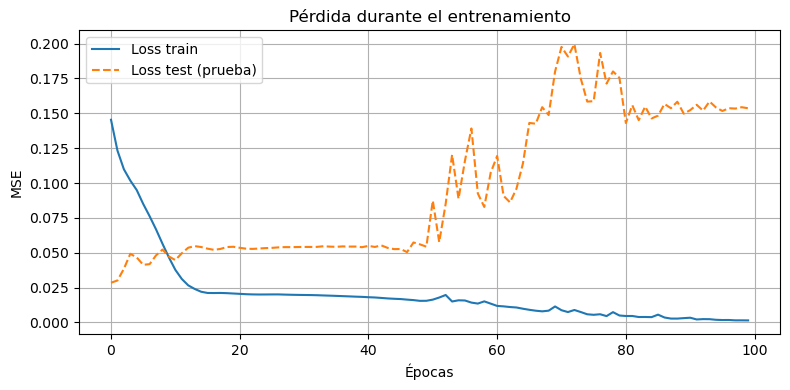

In [22]:
# Evolución de la pérdida durante el entrenamiento
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],     label='Loss train')
plt.plot(history.history['val_loss'], label='Loss test (prueba)', linestyle='--')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, 'loss_entrenamiento.png'), dpi=130, bbox_inches='tight')
plt.show()

ENTRENAMIENTO (datos vistos por el modelo)
[TRAIN] m1...m6 → m7  MAE=0.2758  RMSE=0.3667  R2=0.9897


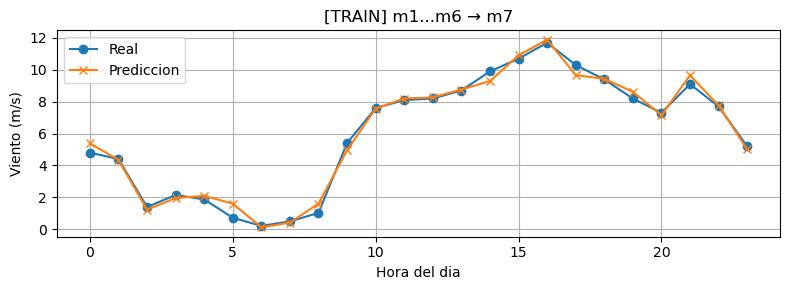

[TRAIN] m2...m7 → m8  MAE=0.2871  RMSE=0.3492  R2=0.9862


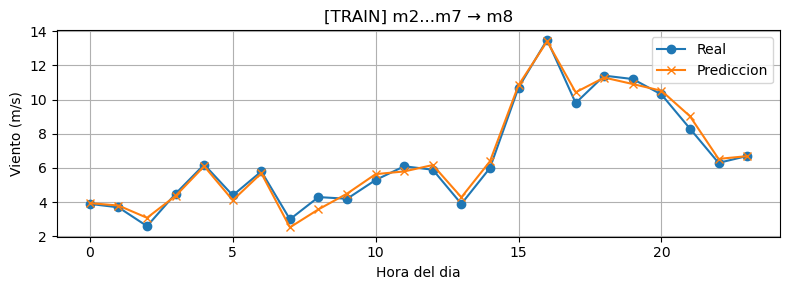

[TRAIN] m3...m8 → m9  MAE=0.6615  RMSE=0.8677  R2=0.8164


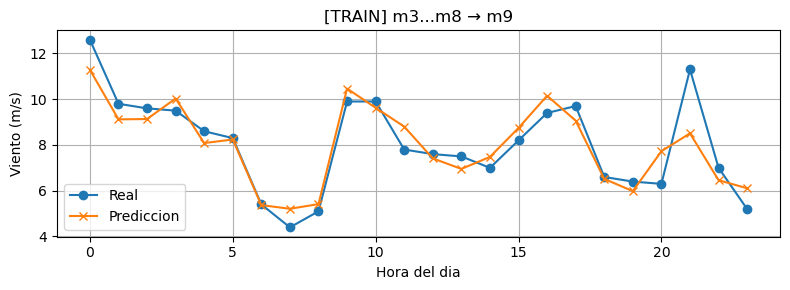

[TRAIN] m4...m9 → m10  MAE=0.8038  RMSE=0.9664  R2=0.8116


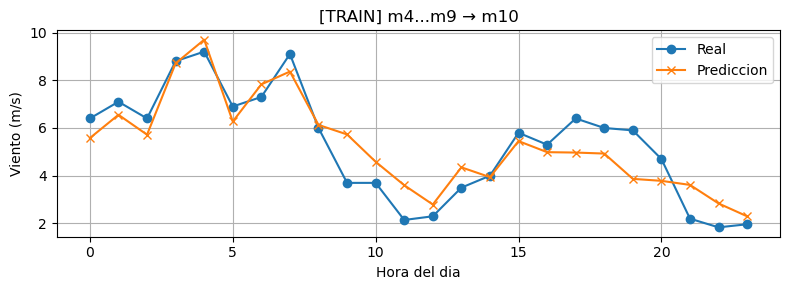

[TRAIN] m5...m10 → m11  MAE=0.5630  RMSE=0.7651  R2=0.8592


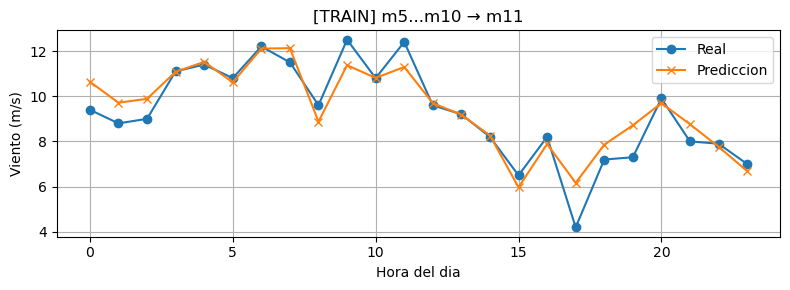


PRUEBA - FUERA DE MUESTRA (datos NO vistos por el modelo)
[TEST] m6...m11 → m12  MAE=5.8589  RMSE=7.7604  R2=-14.8505


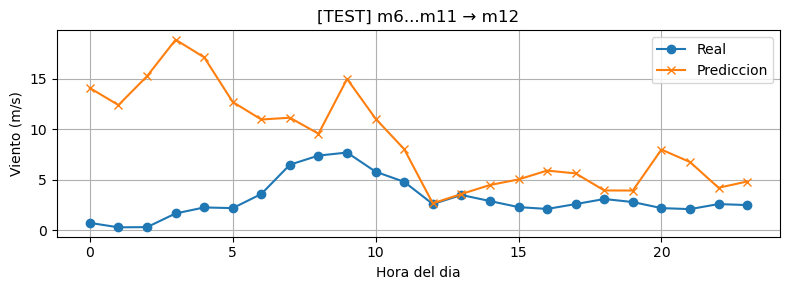


RESUMEN DE METRICAS (usar para la Tabla 15):
       Ventana                  Conjunto  MAE (m/s)  RMSE (m/s)       R2
  m1...m6 → m7             Entrenamiento     0.2758      0.3667   0.9897
  m2...m7 → m8             Entrenamiento     0.2871      0.3492   0.9862
  m3...m8 → m9             Entrenamiento     0.6615      0.8677   0.8164
 m4...m9 → m10             Entrenamiento     0.8038      0.9664   0.8116
m5...m10 → m11             Entrenamiento     0.5630      0.7651   0.8592
m6...m11 → m12 Prueba (fuera de muestra)     5.8589      7.7604 -14.8505

Guardado: metricas_LSTM_resumen.csv  (6 filas)
NOTA: SOLO la fila 'Prueba (fuera de muestra)' es validacion independiente.


In [23]:
# Evaluacion sobre el conjunto de entrenamiento y el de prueba
def evaluar_muestra(idx_global, label=""):
    pred_scaled = model.predict(X[idx_global:idx_global+1], verbose=0)[0]
    real_scaled = y[idx_global]
    real = scaler.inverse_transform(real_scaled.reshape(-1,1)).flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    mae  = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2   = r2_score(real, pred)
    print("[" + label + "] " + etiquetas[idx_global] + "  MAE=" + format(mae,".4f") + "  RMSE=" + format(rmse,".4f") + "  R2=" + format(r2,".4f"))
    plt.figure(figsize=(8,3))
    plt.plot(real, label="Real", marker="o"); plt.plot(pred, label="Prediccion", marker="x")
    plt.title("[" + label + "] " + etiquetas[idx_global]); plt.xlabel("Hora del dia"); plt.ylabel("Viento (m/s)")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.savefig(os.path.join(DIR_FIG, "eval_" + label + "_" + str(idx_global) + ".png"), dpi=130, bbox_inches="tight"); plt.show()
    return mae, rmse, r2

filas = []

print("="*72)
print("ENTRENAMIENTO (datos vistos por el modelo)")
print("="*72)
for i in range(split):
    mae, rmse, r2 = evaluar_muestra(i, "TRAIN")
    filas.append([etiquetas[i], "Entrenamiento", round(mae,4), round(rmse,4), round(r2,4)])

print("")
print("="*72)
print("PRUEBA - FUERA DE MUESTRA (datos NO vistos por el modelo)")
print("="*72)
for i in range(split, len(etiquetas)):
    mae, rmse, r2 = evaluar_muestra(i, "TEST")
    filas.append([etiquetas[i], "Prueba (fuera de muestra)", round(mae,4), round(rmse,4), round(r2,4)])

resumen = pd.DataFrame(filas, columns=["Ventana", "Conjunto", "MAE (m/s)", "RMSE (m/s)", "R2"])
print("")
print("RESUMEN DE METRICAS (usar para la Tabla 15):")
print(resumen.to_string(index=False))
resumen.to_csv(os.path.join(DIR_METRICS, "metricas_LSTM_resumen.csv"), index=False, encoding="utf-8-sig")
print("")
print("Guardado: metricas_LSTM_resumen.csv  (" + str(len(filas)) + " filas)")
print("NOTA: SOLO la fila 'Prueba (fuera de muestra)' es validacion independiente.")

In [24]:
# Exportar predicciones a CSV (usa el único escalador ajustado en entrenamiento)
output_dir = DIR_PRED
os.makedirs(output_dir, exist_ok=True)
for i in range(len(etiquetas)):
    pred_scaled = model.predict(X[i:i+1])[0]
    real_scaled = y[i]
    real = scaler.inverse_transform(real_scaled.reshape(-1,1)).flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    horas = [format(h,"02d") + ":00" for h in range(24)]
    resultados = pd.DataFrame({"Hora": horas, "Real": real, "Prediccion": pred})
    nombre = output_dir + "/Prediccion_" + etiquetas[i].replace(" ","").replace("→","a") + ".csv"
    resultados.to_csv(nombre, index=False)
    print(" CSV guardado:", nombre)

# =====================================================================
#  GENERAR velocidad_viento.xlsx  (entrada de viento para el modelo UC)
#  La columna de viento = prediccion de 24 h de la ventana m1..m6 -> m7
#  (primera ventana, indice 0), es decir la columna "Prediccion".
# =====================================================================
pred0 = model.predict(X[0:1])[0]
pred0 = scaler.inverse_transform(pred0.reshape(-1, 1)).flatten()
df_vv = pd.DataFrame({"Periodo": list(range(1, 25)),
                      "Disponibilidad Viento m/s": pred0})
ruta_vv = os.path.join(DIR_WIND, "velocidad_viento.xlsx")
df_vv.to_excel(ruta_vv, index=False)
print("Generado para el modelo UC:", ruta_vv)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m1...m6am7.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m2...m7am8.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m3...m8am9.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m4...m9am10.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m5...m10am11.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
 CSV guardado: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\PREDICTIONS/Prediccion_m6...m11am12.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Generado para el modelo UC: C:\TESIS_UC\ENTREGABLES\LSTM PREDICTION\OUTPUT\WIND_FORECAST\velocidad_viento.xlsx
